In [9]:
import load_bls as bls
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd

In [2]:
unrate = bls.time_series.get_unrate()

unrate.head()

,date,series_id,year,period,value,lfst_code,periodicity_code,series_title,absn_code,activity_code,...,wkst_code,born_code,chld_code,disa_code,seasonal,tlwk_code,begin_year,begin_period,end_year,end_period
468520,1948-01-01,LNS14000000,1948,M01,3.4,40,M,(Seas) Unemployment Rate,0,0,...,00,00,00,00,S,00,1948,M01,2026,M01
468521,1948-02-01,LNS14000000,1948,M02,3.8,40,M,(Seas) Unemployment Rate,0,0,...,00,00,00,00,S,00,1948,M01,2026,M01
468522,1948-03-01,LNS14000000,1948,M03,4.0,40,M,(Seas) Unemployment Rate,0,0,...,00,00,00,00,S,00,1948,M01,2026,M01
468523,1948-04-01,LNS14000000,1948,M04,3.9,40,M,(Seas) Unemployment Rate,0,0,...,00,00,00,00,S,00,1948,M01,2026,M01
468524,1948-05-01,LNS14000000,1948,M05,3.5,40,M,(Seas) Unemployment Rate,0,0,...,00,00,00,00,S,00,1948,M01,2026,M01


In [3]:
fig = px.line(
    unrate,
    x = "date",
    y = "value",
    title = "Unemployment Rate"
)
fig.show()

In [11]:
# Create a basic line figure without extra Plotly toolbar interactions
fig = px.line(
    unrate,
    x="date",
    y="value",
    title="U.S. Unemployment Rate"
)

# Highlight the most recent point
latest_date = unrate["date"].iloc[-1]
latest_value = unrate["value"].iloc[-1]

fig.add_trace(
    go.Scatter(
        x=[latest_date],
        y=[latest_value],
        mode="markers+text",
        marker=dict(color="red", size=12),
        text=[f"{latest_value:.1f}%"],
        textposition="top center",
        showlegend=False
    )
)

# Optional: add a rolling average line for trend
if len(unrate) >= 3:
    unrate["rolling_3"] = unrate["value"].rolling(3).mean()
    fig.add_trace(
        go.Scatter(
            x=unrate["date"],
            y=unrate["rolling_3"],
            mode="lines",
            line=dict(dash="dash", color="blue"),
            name="3-Month Rolling Avg"
        )
    )

# Update layout for clean dashboard look
fig.update_layout(
    template="plotly_white",
    title={
        "text": "U.S. Unemployment Rate (Monthly)",
        "x": 0.5,
        "xanchor": "center",
    },
    xaxis_title="Date",
    yaxis_title="Unemployment Rate (%)",
    font=dict(family="Arial", size=14, color="#2a3f5f"),
    xaxis=dict(
        showgrid=True,
        gridcolor="#e6e6e6",
        tickformat="%b %Y"
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor="#e6e6e6",
        ticksuffix="%"
    ),
    margin=dict(l=60, r=40, t=80, b=60),
    hovermode="x unified",  # cleaner hover
)

# Disable unnecessary interactive tools (lasso, box select)
fig.update_layout(
    dragmode=False,
    hoverlabel=dict(bgcolor="white", font_size=13)
)

fig.show()

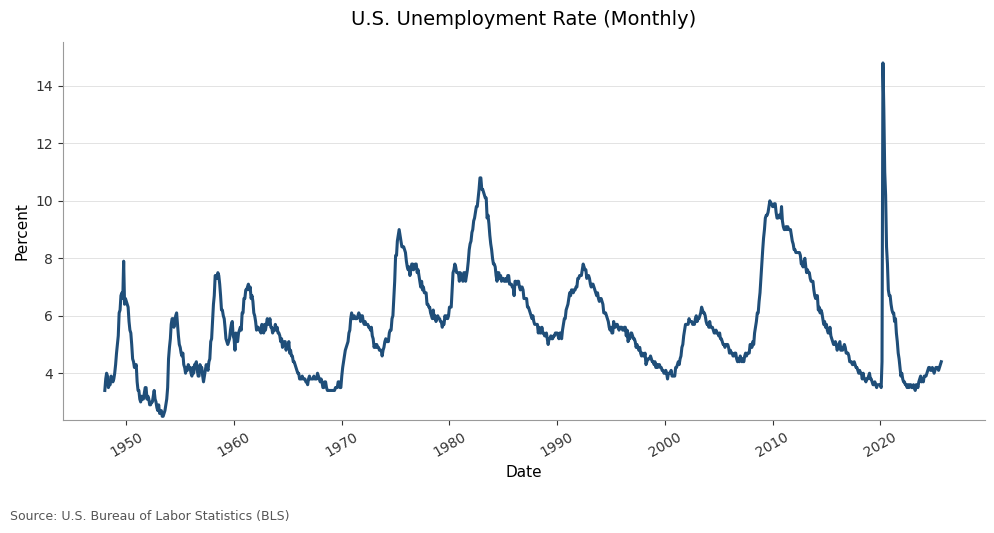

In [13]:
#plt.style.use("default")
fig, ax = plt.subplots(figsize=(10, 5))

# Professional econ palette
line_color = "#1f4e79"      # deep policy blue
grid_color = "#d0d0d0"      # light gray
spine_color = "#9a9a9a"     # muted gray

# Main line
ax.plot(
    unrate["date"],
    unrate["value"],
    color=line_color,
    linewidth=2.2
)

# Titles and labels
ax.set_title(
    "U.S. Unemployment Rate (Monthly)",
    fontsize=14,
    pad=12
)
ax.set_ylabel("Percent", fontsize=11)
ax.set_xlabel("Date", fontsize=11)

# Grid: horizontal only, very subtle
ax.grid(
    axis="y",
    linestyle="-",
    linewidth=0.6,
    color=grid_color,
    alpha=0.7
)
ax.grid(axis="x", visible=False)

# Ticks
ax.tick_params(axis="both", labelsize=10, colors="#333333")

# Spines: minimal, intentional
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(spine_color)
ax.spines["bottom"].set_color(spine_color)

# Y-limits with breathing room
ymin = unrate["value"].min()
ymax = unrate["value"].max()
ax.set_ylim(ymin * 0.95, ymax * 1.05)

# Date formatting
plt.xticks(rotation=30)

# Source note (very econ)
fig.text(
    0.01, -0.05,
    "Source: U.S. Bureau of Labor Statistics (BLS)",
    fontsize=9,
    color="#555555"
)

plt.tight_layout()
plt.show()